In [1]:
import utils_FaIR_JAX
import utils_inverse
import jax
import matplotlib.pyplot as plt
import numpy as np


## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

In [3]:
agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
emis_dict_tier1_JAX, emis_dict_tier2_JAX, emis_dict_DECK_JAX, emis_dict_CS3_JAX = utils_FaIR_JAX.generate_JAX_data(agents, CS3=True)
test_sets = {
    "Tier 1": emis_dict_tier1_JAX,
    "Tier 2": emis_dict_tier2_JAX,
    "DECK": emis_dict_DECK_JAX,
    "CS3": emis_dict_CS3_JAX,
    "All": emis_dict_tier1_JAX | emis_dict_tier2_JAX | emis_dict_DECK_JAX | emis_dict_CS3_JAX
}

emis_dict_train_FaIR, emis_dict_test_FaIR, emis_dict_train_JAX, emis_dict_test_JAX, delT_dict_train_FaIR, delT_dict_test_FaIR, delT_dict_train_JAX, delT_dict_test_JAX = utils_FaIR_JAX.generate_train_test(agents)

train_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_train_JAX)
test_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_test_JAX)
train_s, test_s, stats = utils_inverse.split_and_scale(train_data, test_data)

idx_demo = 1
params0 = utils_inverse.create_baseline(train_s, test_s, idx_demo, verbose=False)

KeyboardInterrupt: 

In [4]:
paramsK_base, baseline_results, baseline_preds, ground_truth = utils_inverse.evaluate_baseline_over_multiple_tests(
    emis_dict_train=emis_dict_tier1_JAX,
    test_sets=test_sets,
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    hidden=32,
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

In [5]:
for test_set in baseline_results:
    if (test_set == 'Tier 2' or test_set == 'CS3') and 'historical' in baseline_results[test_set]:
        baseline_results[test_set].pop('historical')
    per_scen = baseline_results[test_set]
    mean_err = baseline_results[test_set]['mean']
    print(f"\n{test_set} mean scaled RMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")


Tier 1 mean scaled RMSE: 0.0320
  historical                      0.0498
  H-ext                           0.0193
  M                               0.0134
  ML                              0.0157
  L                               0.0442
  VLLO-ext                        0.0417
  VLHO                            0.0399

Tier 2 mean scaled RMSE: 0.0627
  H-ext-OS                        0.0661
  M-ext                           0.0728
  ML-ext                          0.0882
  L-ext                           0.0262
  VLHO-ext                        0.0728

DECK mean scaled RMSE: 0.0525
  abrupt-4xCO2                    0.0600
  1pctCO2                         0.0449

CS3 mean scaled RMSE: 0.0463
  AA                              0.0512
  CT                              0.0113

All mean scaled RMSE: 0.0528
  historical                      0.0764
  H-ext                           0.0193
  M                               0.0111
  ML                              0.0126
  L                    

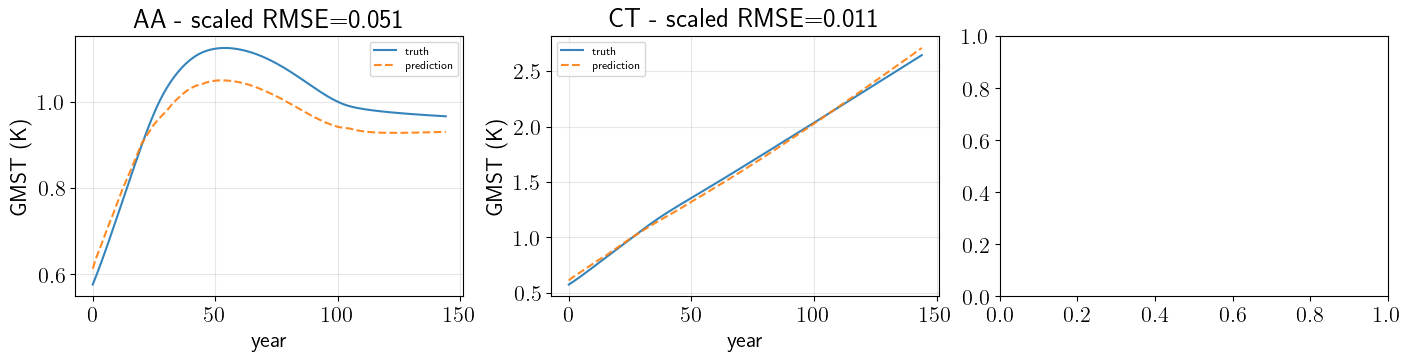

In [6]:
test_set = 'CS3'
N_scens = len(baseline_results[test_set])
rows = int(np.ceil(N_scens / 3))
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5*rows), constrained_layout=True)
axes = axes.ravel()

for i, scen in enumerate(baseline_results[test_set]):
    if scen == 'mean':
        continue
    ax = axes[i]
    ax.plot(ground_truth[test_set][scen],  label="truth", alpha=0.9)
    ax.plot(baseline_preds[test_set][scen],  label="prediction", ls="--", alpha=0.9)
    ax.set_title(f"{scen} - scaled RMSE={baseline_results[test_set][scen]:.3f}")
    ax.set_xlabel("year")
    ax.set_ylabel("GMST (K)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

In [2]:
training_paths = ['checkpoints/co2/inverse_constant_tier1_co2_only_new.pkl',
                  'checkpoints/co2/inverse_constant_tier2_co2_only_new.pkl',
                  'checkpoints/co2/inverse_constant_DECK_co2_only_new.pkl',
                  'checkpoints/co2/inverse_constant_CS3_co2_only_new.pkl',
                  'checkpoints/co2/inverse_constant_all_co2_only_new.pkl']
optimal_results = utils_inverse.evaluate_optimal_emulator(
    training_paths=training_paths,
    test_sets=test_sets,
    params0=params0,
    active_agents=('CO2'),
    inactive_mode="zeros",
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

NameError: name 'test_sets' is not defined

In [16]:
for test_set in optimal_results[training_paths[0]]['metrics']:
    if (test_set == 'Tier 2' or test_set == 'CS3') and 'historical' in optimal_results[training_paths[0]]['metrics'][test_set]:
        optimal_results[training_paths[0]]['metrics'][test_set].pop('historical')
    per_scen = optimal_results[training_paths[0]]['metrics'][test_set]
    mean_err = optimal_results[training_paths[0]]['metrics'][test_set]['mean']
    print(f"\n{test_set} mean scaled RMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")


Tier 1 mean scaled RMSE: 0.0226
  historical                      0.0095
  H-ext                           0.0330
  M                               0.0138
  ML                              0.0143
  L                               0.0406
  VLLO-ext                        0.0101
  VLHO                            0.0368

Tier 2 mean scaled RMSE: 0.0500
  H-ext-OS                        0.0360
  M-ext                           0.0393
  ML-ext                          0.1416
  L-ext                           0.0318
  VLHO-ext                        0.0418

DECK mean scaled RMSE: 0.0671
  abrupt-4xCO2                    0.0796
  1pctCO2                         0.0547

CS3 mean scaled RMSE: 0.0310
  AA                              0.0565
  CT                              0.0283

All mean scaled RMSE: 0.0445
  historical                      0.0082
  H-ext                           0.0345
  M                               0.0170
  ML                              0.0176
  L                    

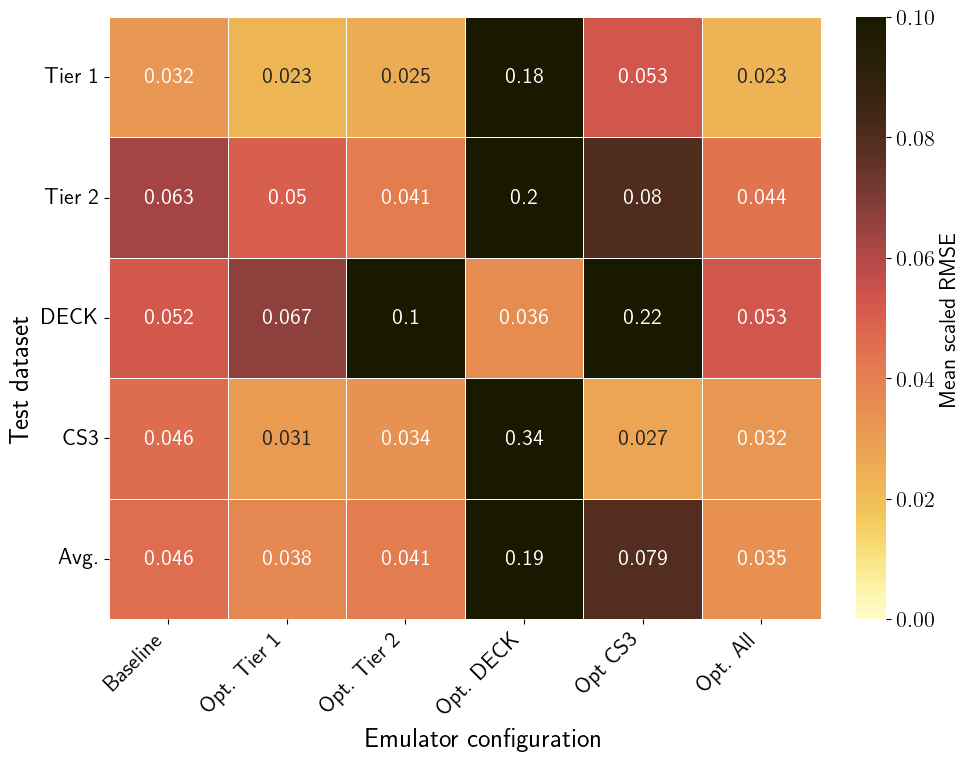

In [18]:
train_scenarios = ['Opt. Tier 1', 'Opt. Tier 2', 'Opt. DECK', 'Opt CS3', 'Opt. All']
test_scenarios = ['Tier 1', 'Tier 2', 'DECK', 'CS3']
weights = [7, 5, 2, 2]
vmax = 0.1
plot_single_heatmap(baseline_results, optimal_results, train_scenarios, test_scenarios, training_paths, weights, vmax, save=True)

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from cmcrameri import cm

def plot_single_heatmap(baseline_results: dict,
                        optimized_results: dict,
                        train_scenarios: list[str],
                        test_scenarios: list[str],
                        training_paths: list[str],
                        weights: list[int],
                        vmax: float,
                        cmap: str = cm.lajolla_r,
                        long_title: str = '',
                        save: bool=False,
                        figname: str='') -> None:
  """
  Draws a comparison heatmap: Baseline vs Optimized results.

  Rows (Y-axis): Test Sets
  Cols (X-axis): Baseline (Col 0) + Optimized Results per Training Path (Cols 1..N)

  Parameters
  ----------
  baseline_results : dict
    Errors indexed as baseline_results[test_set]['mean'].
  optimized_results : dict
    Errors indexed as optimized_results[training_path]['metrics'][test_set]['mean'].
  train_scenarios : list[str]
    List of training path keys (determines columns 1 to N).
  test_scenarios : list[str]
    List of test set keys (determines rows).
  ax : matplotlib.axes.Axes
    Target axis for the heat-map.
  vmax : float
    Colour-scale maximum (min is fixed at 0).
  cmap : str, optional
    Matplotlib/SNS colour-map (default "Reds").
  long_title : str, optional
    Sub-plot title.
  add_cbar : bool, optional
    Add colour-bar on this axis when True.

  Returns
  -------
  None
  """
  # Dimensions: Rows = 1 (Avg.) + N (Test Sets), Columns = 1 (Baseline) + N (Training Scenarios)
  n_test = len(test_scenarios)
  n_rows = 1 + n_test
  n_cols = 1 + len(train_scenarios)

  fig, ax = plt.subplots(figsize=(8 * n_cols / 5, 6 * n_rows / 4), sharex='col', constrained_layout=True)

  # Instantiate data array
  data = np.empty((n_rows, n_cols))

  # --- Fill Column 0: Baseline Results ---
  for i, scen_test in enumerate(test_scenarios):
    try:
      # Access: baseline_results[test_set]['mean']
      value = baseline_results[scen_test]['mean']
    except KeyError:
      value = np.nan
    data[i, 0] = value

  # --- Fill Columns 1 to N: Optimized Results ---
  for j, path in enumerate(training_paths):
    col_idx = j + 1  # Offset by 1 because col 0 is baseline
    for i, scen_test in enumerate(test_scenarios):
      try:
        value = optimized_results[path]['metrics'][scen_test]['mean']
      except KeyError:
        value = np.nan
      data[i, col_idx] = value

  w_arr = np.array(weights)
  for col in range(n_cols):
    # Slice the column data corresponding to the test scenarios (exclude the last empty row)
    col_data = data[:n_test, col]

    # Calculate weighted average
    # Note: If col_data contains NaNs, the result will be NaN.
    # Use np.ma.average if you wish to ignore NaNs, but standard np.average is used here.
    try:
      avg_val = np.average(col_data, weights=w_arr)
    except Exception:
      avg_val = np.nan

    data[n_test, col] = avg_val

  # Plot the heatmap
  sns.heatmap(
    data,
    ax=ax,
    cmap=cmap,
    vmin=0,
    vmax=vmax,
    linewidth=0.5,
    annot=True,
    fmt=".2g",
    cbar=True,
    cbar_kws={"label": r"Mean scaled RMSE"}
  )

  # Configure labels and title
  ax.set_title(long_title)

  # Generate dynamic labels based on inputs
  # X-labels: "Baseline" followed by the training scenario names
  x_tick_labels = ['Baseline'] + train_scenarios
  # Y-labels: The test scenario names
  y_tick_labels = test_scenarios + ['Avg.']
  ax.set_xticklabels(x_tick_labels, rotation=45, ha="right")
  ax.set_yticklabels(y_tick_labels, rotation=0) # Typically horizontal for Y-axis looks better

  fig.supxlabel('Emulator configuration')
  fig.supylabel('Test dataset')

  if save:
    plt.savefig(f'Figures/{figname}.pdf')

  return

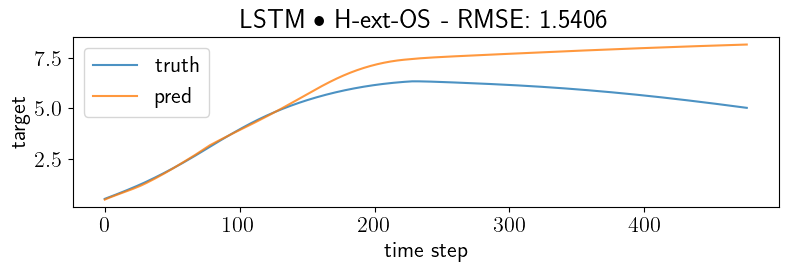

||grad BC||: 0.0012314581545069814
||grad CH4||: 3.0665767553728074e-05
||grad CO2||: 0.00027943766326643527
||grad N2O||: 0.0006393713410943747
||grad Sulfur||: 0.00017973955255001783


In [3]:
agents = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
emis_dict_train_FaIR, emis_dict_test_FaIR, emis_dict_train_JAX, emis_dict_test_JAX, delT_dict_train_FaIR, delT_dict_test_FaIR, delT_dict_train_JAX, delT_dict_test_JAX = utils_FaIR_JAX.generate_train_test(agents)

train_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_train_JAX)
test_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_test_JAX)
train_s, test_s, stats = utils_inverse.split_and_scale(train_data, test_data)

idx_demo = 1
params0 = utils_inverse.create_baseline(train_s, test_s, idx_demo, verbose=False)

test_scen = 'historical'
utils_inverse.test_get_grad(test_scen, params0, emis_dict_train_JAX, train_data, test_data, active=("CO2","CH4", "N2O", "Sulfur", "BC"))

In [4]:
emis_dict_tier1_JAX, emis_dict_tier2_JAX, emis_dict_DECK_JAX, emis_dict_CS3_JAX, emis_dict_DAMIP_JAX, emis_dict_GeoMIP_JAX = utils_FaIR_JAX.generate_JAX_data(agents, CS3=True, DAMIP=True, GeoMIP=True)
emis_dict_all_JAX = emis_dict_tier1_JAX | emis_dict_tier2_JAX | emis_dict_DECK_JAX | emis_dict_CS3_JAX | emis_dict_DAMIP_JAX | emis_dict_GeoMIP_JAX
test_sets = {
    "Tier 1": emis_dict_tier1_JAX,
    "Tier 2": emis_dict_tier2_JAX,
    "DECK": emis_dict_DECK_JAX,
    "CS3": emis_dict_CS3_JAX,
    "DAMIP": emis_dict_DAMIP_JAX,
    "GeoMIP": emis_dict_GeoMIP_JAX,
    "All": emis_dict_all_JAX
}

In [5]:
paramsK_base, baseline_results, baseline_preds, ground_truth = utils_inverse.evaluate_baseline_over_multiple_tests(
    emis_dict_train=emis_dict_tier1_JAX,
    test_sets=test_sets,
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    hidden=32,
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

for test_set in baseline_results:
    per_scen = baseline_results[test_set]
    mean_err = baseline_results[test_set]['mean']
    print(f"\n{test_set} mean scaled RMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")


Tier 1 mean scaled RMSE: 0.0864
  historical                      0.1754
  H-ext                           0.0055
  M                               0.0462
  ML                              0.0509
  L                               0.1502
  VLLO-ext                        0.0690
  VLHO                            0.1078

Tier 2 mean scaled RMSE: 0.2583
  historical                      0.1754
  H-ext-OS                        0.2430
  M-ext                           0.3866
  ML-ext                          0.2531
  L-ext                           0.2272
  VLHO-ext                        0.2643

DECK mean scaled RMSE: 1.2346
  abrupt-4xCO2                    0.7407
  abrupt-4xCH4                    0.4440
  abrupt-4xN2O                    4.2212
  abrupt-4xSulfur                 0.1344
  abrupt-4xBC                     0.0620
  1pctCO2                         0.3768
  1pctCH4                         0.2691
  1pctN2O                         4.6978
  1pctSulfur                      0.7244
 

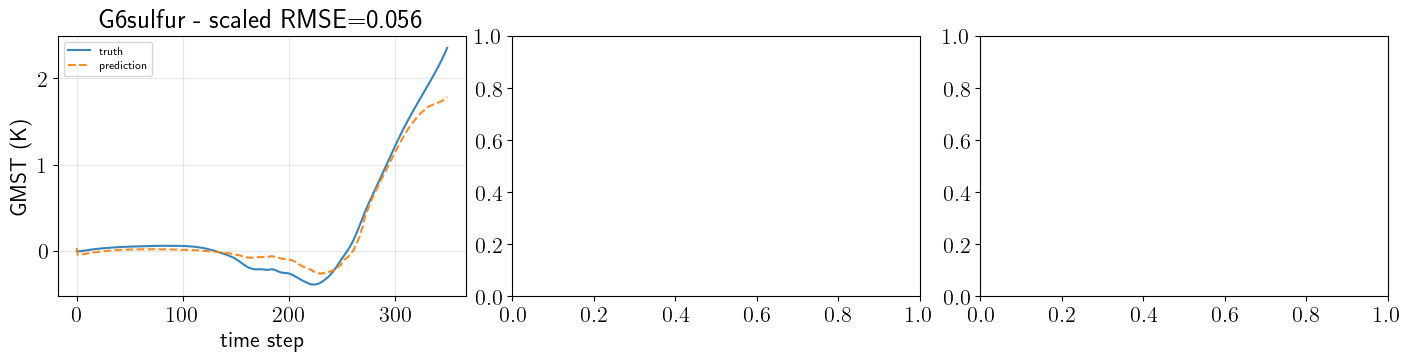

In [6]:
test_set = 'GeoMIP'
N_scens = len(baseline_results[test_set])
rows = int(np.ceil(N_scens / 3))
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5*rows), constrained_layout=True)
axes = axes.ravel()

for i, scen in enumerate(baseline_results[test_set]):
    if scen == 'mean':
        continue
    ax = axes[i]
    ax.plot(ground_truth[test_set][scen],  label="truth", alpha=0.9)
    ax.plot(baseline_preds[test_set][scen],  label="prediction", ls="--", alpha=0.9)
    ax.set_title(f"{scen} - scaled RMSE={baseline_results[test_set][scen]:.3f}")
    ax.set_xlabel("time step")
    ax.set_ylabel("GMST (K)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

In [9]:
training_paths = ['checkpoints/multi/inverse_constant_tier1_all_ghgs.pkl',
                  'checkpoints/multi/inverse_constant_tier2_all_ghgs.pkl',
                  'checkpoints/multi/inverse_constant_DECK_all_ghgs.pkl',
                  'checkpoints/multi/inverse_constant_CS3_all_ghgs.pkl',
                  'checkpoints/multi/inverse_constant_DAMIP_all_ghgs.pkl',
                  'checkpoints/multi/inverse_constant_GeoMIP_all_ghgs.pkl',
                  'checkpoints/multi/inverse_constant_all_all_ghgs.pkl']
optimal_results = utils_inverse.evaluate_optimal_emulator(
    training_paths=training_paths,
    test_sets=test_sets,
    params0=params0,
    active_agents=('CO2','CH4','N2O','Sulfur','BC'),
    inactive_mode="zeros",
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    hidden=32,
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

In [10]:
for test_set in optimal_results[training_paths[0]]['metrics']:
    if (test_set == 'Tier 2' or test_set == 'CS3') and 'historical' in optimal_results[training_paths[0]]['metrics'][test_set]:
        optimal_results[training_paths[0]]['metrics'][test_set].pop('historical')
    per_scen = optimal_results[training_paths[0]]['metrics'][test_set]
    mean_err = optimal_results[training_paths[0]]['metrics'][test_set]['mean']
    print(f"\n{test_set} mean scaled RMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")


Tier 1 mean scaled RMSE: 0.0233
  historical                      0.0248
  H-ext                           0.0238
  M                               0.0047
  ML                              0.0042
  L                               0.0569
  VLLO-ext                        0.0364
  VLHO                            0.0124

Tier 2 mean scaled RMSE: 0.1286
  H-ext-OS                        0.0839
  M-ext                           0.2016
  ML-ext                          0.1798
  L-ext                           0.1370
  VLHO-ext                        0.1445

DECK mean scaled RMSE: 1.1470
  abrupt-4xCO2                    0.3340
  abrupt-4xCH4                    0.9242
  abrupt-4xN2O                    0.9017
  abrupt-4xSulfur                 0.2602
  abrupt-4xBC                     0.1928
  1pctCO2                         0.0440
  1pctCH4                         0.2871
  1pctN2O                         0.8581
  1pctSulfur                      1.4542
  1pctBC                          6.2139



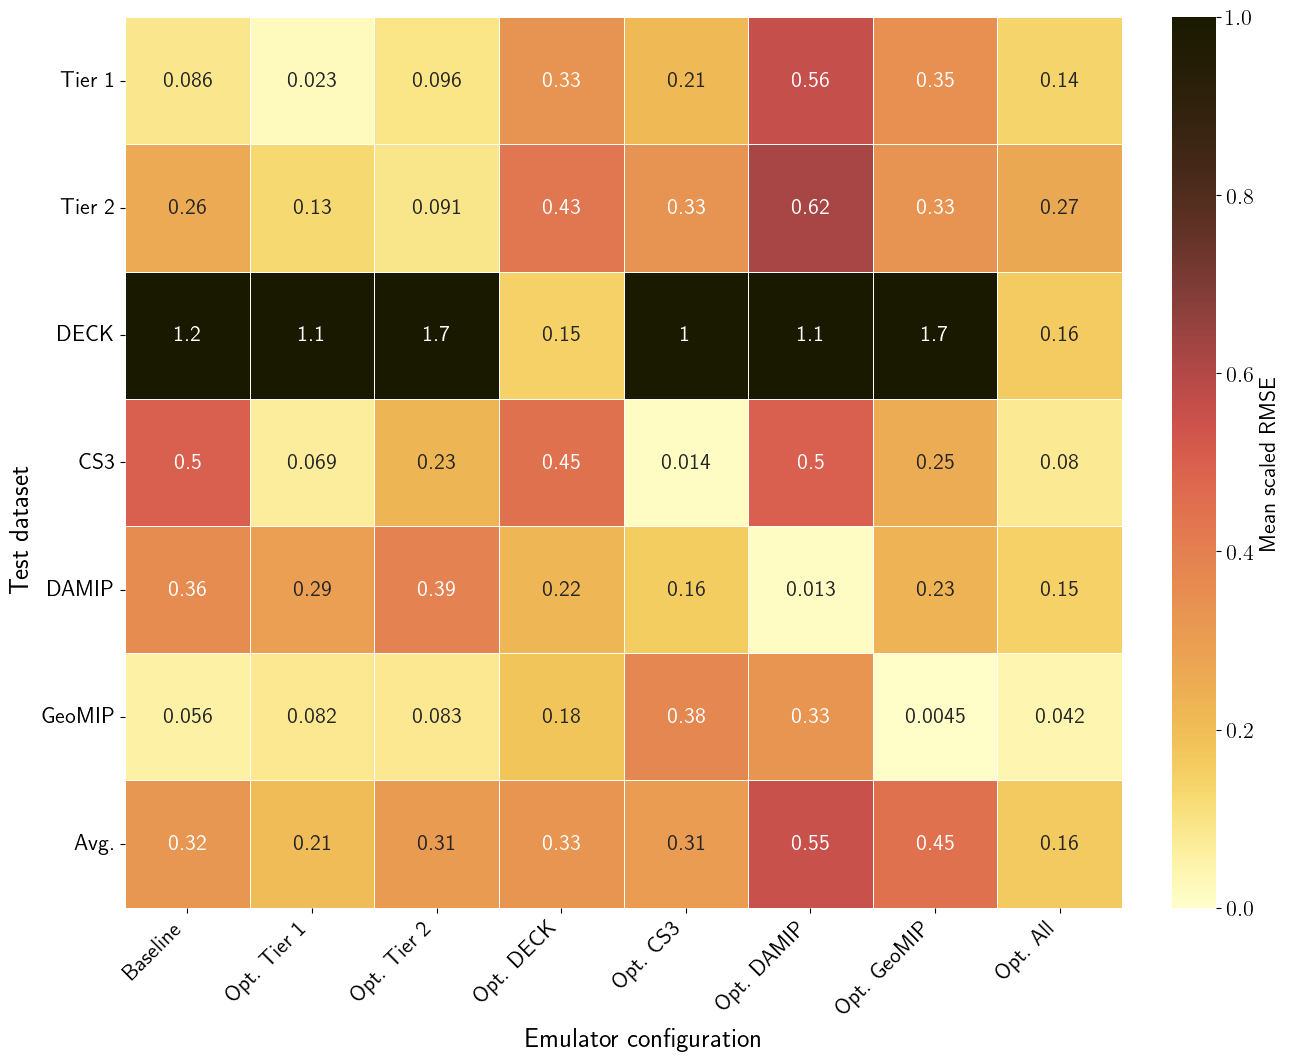

In [16]:
train_scenarios = ['Opt. Tier 1', 'Opt. Tier 2', 'Opt. DECK', 'Opt. CS3', 'Opt. DAMIP', 'Opt. GeoMIP', 'Opt. All']
test_scenarios = ['Tier 1', 'Tier 2', 'DECK', 'CS3', 'DAMIP', 'GeoMIP']
weights = [7, 5, 2, 2, 2, 1]
vmax = 1
plot_single_heatmap(baseline_results, optimal_results, train_scenarios, test_scenarios, training_paths, weights, vmax, save=True, figname='heatmap_multi')